In [3]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.io import wavfile
from scipy import signal as sig


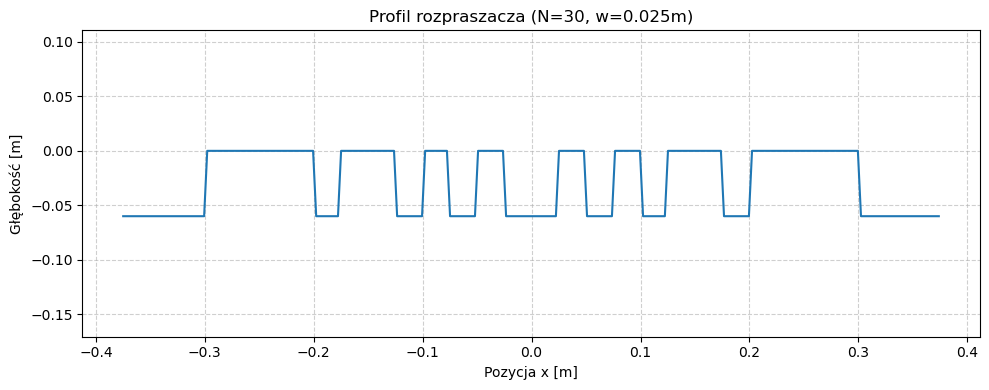

------------------------------
Indeks   | sn   | Głębokość [m]
0        | 1    | 0.0600
1        | 1    | 0.0600
2        | 1    | 0.0600
3        | 0    | 0.0000
4        | 0    | 0.0000
5        | 0    | 0.0000
6        | 0    | 0.0000
7        | 1    | 0.0600
8        | 0    | 0.0000
9        | 0    | 0.0000
10       | 1    | 0.0600
11       | 0    | 0.0000
12       | 1    | 0.0600
13       | 0    | 0.0000
14       | 1    | 0.0600
15       | 1    | 0.0600
16       | 0    | 0.0000
17       | 1    | 0.0600
18       | 0    | 0.0000
19       | 1    | 0.0600
20       | 0    | 0.0000
21       | 0    | 0.0000
22       | 1    | 0.0600
23       | 0    | 0.0000
24       | 0    | 0.0000
25       | 0    | 0.0000
26       | 0    | 0.0000
27       | 1    | 0.0600
28       | 1    | 0.0600
29       | 1    | 0.0600

szer. studzienki = 0.025 m, wymiary calego rozpraszacza = 0.7500 m x 0.6000 m
Zakres częstotliwości: 95.28 Hz - 6860.00 Hz


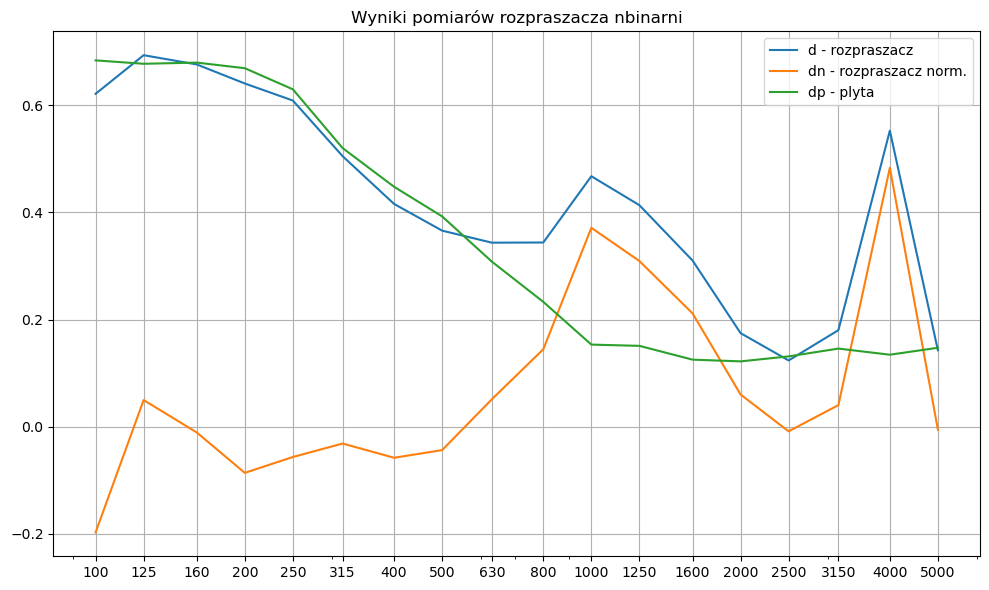

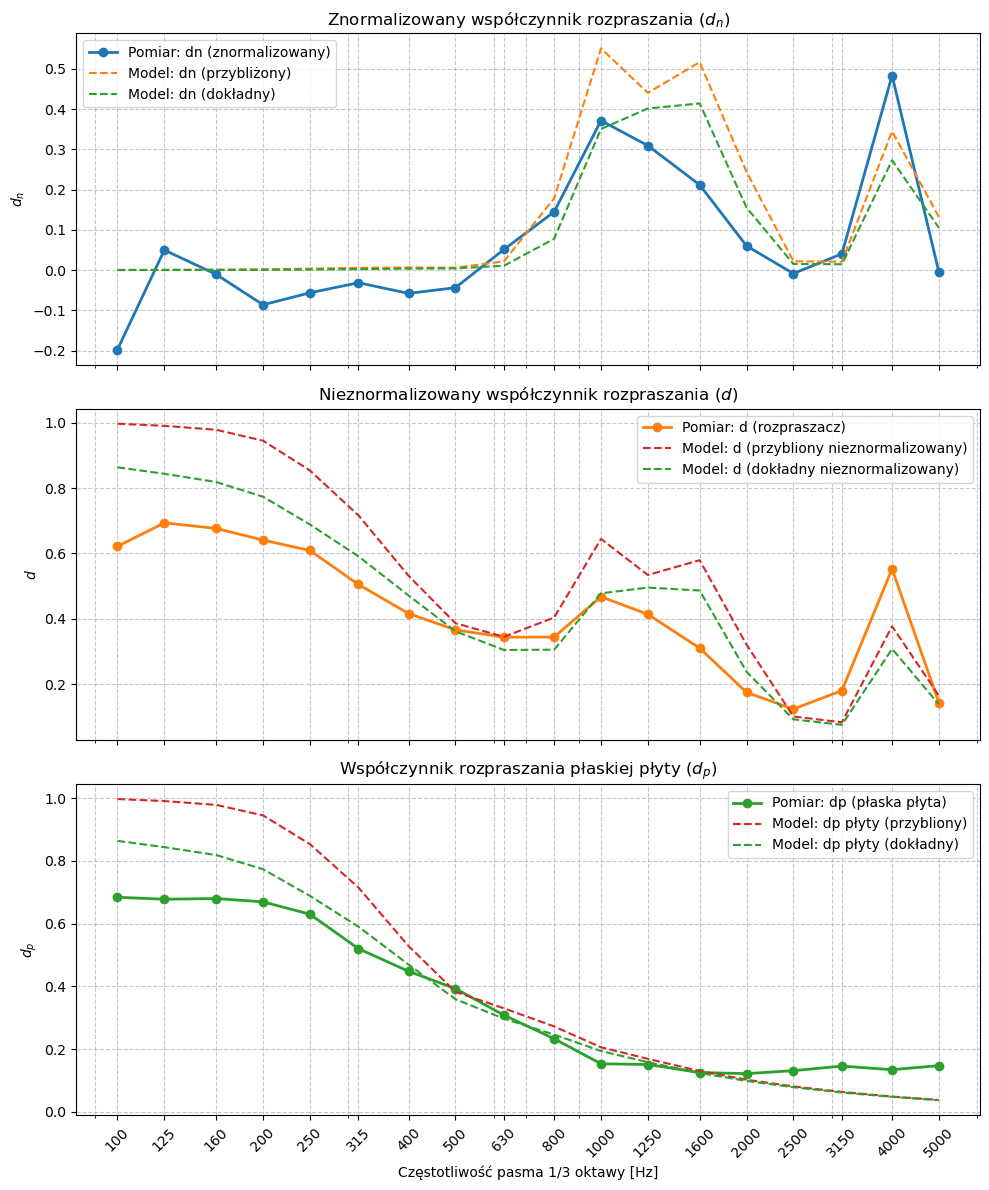

In [4]:
parent = Path('.').resolve().parent
folder_path = parent / "diffuser_meas"

nbinarni_folder = sorted(Path(folder_path / "nbinarni").iterdir())
plyta_folder = sorted(Path(folder_path / "plyta").iterdir())
pusta_folder = sorted(Path(folder_path / "pusta").iterdir())



def import_waves_from_folder_to_array(folder):
    ans_list = []
    sr_mem = None
    for file in folder:
        sr, data = wavfile.read(file)
        if (sr_mem and sr != sr_mem ):
            x = np.linspace(0, 1, 100)
            plt.plot(x, np.sin(np.exp(x)))
            plt.title(f"error inconsistent sample rate in {str(file)}")
            plt.show()
            print("error inconsistent sample rate")
        sr_mem = sr
        ans_list.append(data[:,0])
    return sr, np.array(ans_list)


#############################################
##############################################
##############################################
##############################################


sr, nbinarni_angles = import_waves_from_folder_to_array(nbinarni_folder)
sr, plyta_angles = import_waves_from_folder_to_array(plyta_folder)
sr, pusta_angles = import_waves_from_folder_to_array(pusta_folder)



measures = (nbinarni_angles, plyta_angles, pusta_angles)
measure_names = ("nbinarni", "plyta", "pusta")

_sr = sr
_start = 1500
_stop = 3700
_s = plyta_angles[18]
_time = len(_s)/ sr
_timewekt = np.linspace(0, _time-1/sr, len(_s))

def peek(s, start, stop):
    plt.figure(figsize=(7,2))
    plt.plot(_timewekt[start:stop], s[start:stop])
    plt.tight_layout
    plt.grid()
    plt.show()

    peak_sig = np.max(np.abs(s[start:stop]))
    peak_bg = np.max(np.abs(s[(stop-200):stop]))
    print(20*np.log10(peak_sig/peak_bg))
    print(f"długość wycinka: {(stop-start)/sr:.4f} s.")


def peek_all(what):
    for rec_list in what:
        for i, s in enumerate(rec_list):
            peek(s, _start, _stop)
            print(i)
            


#UWAGA NIE LICZYMY RMS W PUNKCIE 5

def peek_id(idx, what):
    for i, a in enumerate(what):
        peek(a[idx], _start, _stop)
        print(measure_names[i])



# peek_id(18, measures)

# plyta_pusta_diffs = []
# for a, b in zip(plyta_angles, pusta_angles):
#     plyta_pusta_diffs.append(a - b)

# plyta_pusta_diffs = []
# for a, b in zip(plyta_angles, pusta_angles):
#     plyta_pusta_diffs.append(a - b)


nbinarni_pusta_diffs = nbinarni_angles - pusta_angles
plyta_pusta_diffs = plyta_angles - pusta_angles

diffs = (nbinarni_pusta_diffs, plyta_pusta_diffs)
# peek_id(18, diffs)

#poprosiłem gemini o kopię matlabowej funkcji. trochę ją zmieniłem, przy okazji przeczytałem np. o sosfiltfilt 
def thirdsFilterBank(x, fs, f_min=100, f_max=5000, order=3): #funkcja na wzór octavefilterbank z MatLaba
    """
    Filtruje sygnał wejściowy zestawem filtrów tercjowych (Butterworth, zero-phase).
    
    Parametry:
    :param x: 1D array - wektor sygnału wejściowego
    :param fs: int - częstotliwość próbkowania sygnału
    :param f_min: float - minimalna częstotliwość środkowa (domyślnie 100 Hz)
    :param f_max: float - maksymalna częstotliwość środkowa (domyślnie 5000 Hz)
    :param order: int - rząd filtru Butterwortha (domyślnie 3)
    
    Zwraca:
    :return y: 2D array - macierz o kształcie (len(x), liczba_pasm), kolumny to przefiltrowane pasma
    :return fc: 1D array - wektor częstotliwości środkowych dla kolejnych kolumn
    """
    
    # Standardowe, nominalne częstotliwości środkowe pasm tercjowych (z normy ISO)
    nominal_fc = np.array([
        20, 25, 31.5, 40, 50, 63, 80, 100, 125, 160, 200, 250, 315, 400, 500, 630, 800, 
        1000, 1250, 1600, 2000, 2500, 3150, 4000, 5000, 6300, 8000, 10000, 12500, 16000, 20000
    ])
    
    # Zabezpieczenie przed twierdzeniem Nyquista - górna granica filtru nie może przekroczyć fs/2
    nyquist = fs / 2
    
    # Wybieramy tylko te pasma, które mieszczą się w żądanym zakresie i nie łamią Nyquista
    mask = (nominal_fc >= f_min) & (nominal_fc <= f_max) & (nominal_fc * (2**(1/6)) < nyquist)
    fc = nominal_fc[mask]
    
    # Prealokacja macierzy wyjściowej (liczba próbek x liczba pasm)
    y = np.zeros((len(fc), len(x)))
    
    # Generowanie filtrów i filtrowanie sygnału
    for i, center_freq in enumerate(fc):
        # Obliczenie dolnej i górnej częstotliwości odcięcia
        fd = center_freq * (2 ** (-1/6))
        fg = center_freq * (2 ** (1/6))
        
        # Projektowanie filtru typu SOS (Second-Order Sections) - stabilność numeryczna
        sos = sig.butter(N=order, Wn=[fd, fg], btype='bandpass', fs=fs, output='sos')
        
        # Filtrowanie sygnału w przód i w tył (zero-phase), wynik ląduje w i-tej kolumnie
        y[i, :] = sig.sosfiltfilt(sos, x)
        
    return y, fc


####filtrowanie
def filter_into_3d(signal_angles):
    filtered_test, _ = thirdsFilterBank(signal_angles[0], _sr)
    ans_3d = np.zeros((signal_angles.shape[0], filtered_test.shape[0], filtered_test.shape[1] ))
    for i, s in enumerate(signal_angles):
        y, _ = thirdsFilterBank(s, _sr)
        ans_3d[i,:,:] = y
    return ans_3d

nbin_diff_3d = filter_into_3d(nbinarni_pusta_diffs)
plyta_diff_3d = filter_into_3d(plyta_pusta_diffs)

nbin_diff_3d_trimmed = nbin_diff_3d[:,:,_start:_stop]
plyta_diff_3d_trimmed = plyta_diff_3d[:,:,_start:_stop]

nbin_rmss = np.sqrt(np.mean(nbin_diff_3d_trimmed**2, axis = 2))
plyta_rmss = np.sqrt(np.mean(plyta_diff_3d_trimmed**2, axis = 2))

# print(nbin_rmss.shape)

def d_coeff(rmss):
    
    num_thetas = rmss.shape[0]
    ps_sq = np.abs(rmss)**2
    ps_sqsq = ps_sq**2
    thetas_sq_sum = np.sum(ps_sq, axis = 0)
    thetas_sqsq_sum = np.sum(ps_sqsq, axis = 0)
    return np.squeeze(thetas_sq_sum**2 - thetas_sqsq_sum) / (num_thetas - 1) / thetas_sqsq_sum

def d_coeff_norm(rmss, ref_rmss):
    d = d_coeff(rmss)
    d_0 =  d_coeff(ref_rmss)
    return (d - d_0) / (1-d_0), d, d_0

_,f_centers = thirdsFilterBank(nbinarni_angles[0], _sr)

dn, d, dp = d_coeff_norm(nbin_rmss, plyta_rmss)

# print(dn.shape)
f_centers = np.int32(f_centers)

#############################################
#############################################
#############################################
#############################################
#############################################
#############################################


from model_diff import Diffuser, to_thirds, d_coeff_normalised

fc_tercje = np.array([100, 125, 160, 200, 250, 315, 400, 500, 630, 800, 
                      1000, 1250, 1600, 2000, 2500, 3150, 4000, 5000])

nbin = np.array([1,1,1,0,0,0,0,1,0,0,1,0,1,0,1])
nbin = np.append(nbin, nbin[::-1])
# print(nbin)
nbinarni_diff = Diffuser(nbin, 0.06, 0.025, 0.30)
nbinarni_diff.plot()
print(nbinarni_diff)

a, a_raw, a_plyta = d_coeff_normalised(nbinarni_diff, 'a')
b, b_raw, b_plyta = d_coeff_normalised(nbinarni_diff, 'b')


plt.figure(figsize=(10,6))
plt.title("Wyniki pomiarów rozpraszacza nbinarni")
plt.semilogx(f_centers, d, label = "d - rozpraszacz")
plt.semilogx(f_centers, dn, label = "dn - rozpraszacz norm.")
plt.semilogx(f_centers, dp, label = "dp - plyta")
plt.xticks(f_centers, f_centers)
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

#poprosiłem chata o konkretnie taki wykres
# Tworzymy 3 wykresy jeden pod drugim (współdzielona oś X)
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

# --- WYKRES 1: Znormalizowany współczynnik dn (NAJWAŻNIEJSZY) ---
ax1.semilogx(f_centers, dn, label="Pomiar: dn (znormalizowany)", linewidth=2, marker='o')
ax1.semilogx(fc_tercje, to_thirds(a), "--", label="Model: dn (przybliżony)")
ax1.semilogx(fc_tercje, to_thirds(b), "--", label="Model: dn (dokładny)")
ax1.set_title("Znormalizowany współczynnik rozpraszania ($d_n$)")
ax1.set_ylabel("$d_n$")
ax1.grid(True, which="both", ls="--", alpha=0.7)
ax1.legend()

# --- WYKRES 2: Surowy współczynnik d ---
ax2.semilogx(f_centers, d, label="Pomiar: d (rozpraszacz)", linewidth=2, color='tab:orange', marker='o')
ax2.semilogx(fc_tercje, to_thirds(a_raw), "--", label="Model: d (przybliony nieznormalizowany)", color='tab:red')
ax2.semilogx(fc_tercje, to_thirds(b_raw), "--", label="Model: d (dokładny nieznormalizowany)", color='tab:green')
ax2.set_title("Nieznormalizowany współczynnik rozpraszania ($d$)")
ax2.set_ylabel("$d$")
ax2.grid(True, which="both", ls="--", alpha=0.7)
ax2.legend()

# --- WYKRES 3: Płyta referencyjna dp ---
ax3.semilogx(f_centers, dp, label="Pomiar: dp (płaska płyta)", linewidth=2, color='tab:green', marker='o')
ax3.semilogx(fc_tercje, to_thirds(a_plyta), "--", label="Model: dp płyty (przybliony)", color='tab:red')
ax3.semilogx(fc_tercje, to_thirds(b_plyta), "--", label="Model: dp płyty (dokładny)", color='tab:green')
ax3.set_title("Współczynnik rozpraszania płaskiej płyty ($d_p$)")
ax3.set_xlabel("Częstotliwość pasma 1/3 oktawy [Hz]")
ax3.set_ylabel("$d_p$")
ax3.grid(True, which="both", ls="--", alpha=0.7)
ax3.legend()

# Formatowanie wspólnej osi X (logarytmicznej)
ax3.set_xticks(f_centers)
ax3.set_xticklabels(np.array(f_centers, dtype=int), rotation=45)

plt.tight_layout()
plt.show()


